In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

def load_and_prepare_annotations(data_dir_path):
    data = os.path.join(data_dir_path, 'annotation', 'annotations.csv')
    data = pd.read_csv(data)
    data = data[data.filename.str.startswith("2P-fc2")]
    data['annotation'] = data_dir_path + '/pupil_map/' + data.filename.str.replace(r'jpg', 'png')
    data['frame'] = data_dir_path + '/fullFrames/' + data.filename
    return data


def show_image(im, ax=plt):
    if len(im.shape) == 2:
        ax.imshow(im)
    else:
        ax.imshow(im.permute(1, 2, 0))
    ax.axis('off')

def show_images(ann, frame):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(ann.permute(1, 2, 0), cmap='grey')
    ax[0].axis('off')
    ax[1].imshow(frame.permute(1, 2, 0), cmap='grey')
    ax[1].axis('off')

In [2]:
from torchvision.io import decode_image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.transforms import InterpolationMode


class ImageDataset(Dataset):
    def __init__(self, data_dir_path: str):
        super().__init__()
        self._data = load_and_prepare_annotations(data_dir_path)
        
        self.transform_in = v2.Compose([
            v2.ToDtype(torch.uint8, scale=True),
            v2.Resize((334, 334), InterpolationMode.BILINEAR),
            v2.ToDtype(torch.float32, scale=True)
        ])
        
        self.transform_out = v2.Compose([
            v2.ToDtype(torch.uint8, scale=True),
            v2.Resize((244, 244), InterpolationMode.NEAREST),
            v2.ToDtype(torch.float32, scale=True)
        ])

    def __len__(self):
        return len(self._data)

    def __getitem__(self, idx):
        img_data = self._data.iloc[idx]
        input_img = self.transform_in(decode_image(img_data.frame))
        output_img = self.transform_out(decode_image(img_data.annotation))
        output_img = output_img[0].unsqueeze(0)
        return input_img, output_img

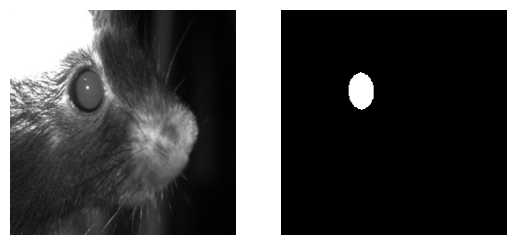

In [3]:
ds = ImageDataset("../datasets/NN_human_mouse_eyes/")
in_image, out_image = ds[25]
show_images(in_image, out_image)

In [10]:
def get_pupil_centre(pmap, datum):
    pmap = pmap.squeeze()
    width, height = pmap.shape
    total_mass = pmap.sum()
    if total_mass > 0:
        x_moment = pmap.sum(1).dot(torch.arange(width, dtype=torch.float)) / total_mass
        y_moment = pmap.sum(0).dot(torch.arange(height, dtype=torch.float)) / total_mass
        result = x_moment, y_moment
    else:
        result = (width / 2, height / 2)

    return torch.tensor(result).int()

# w, h = get_pupil_centre(out_image, meta)
# 
# out_image[0, w, h] = 0.0
# plt.imshow(out_image.permute(1, 2, 0))
# plt.axis('off')

## U-NET architecture

### Encoder

In [11]:
in_image = in_image.unsqueeze(0)
in_image.shape

torch.Size([1, 1, 334, 334])

In [12]:
import torch.nn as nn

class U_NET(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
        self.encoder1 = self._encoder(1, 64)
        self.max_pool_block1 = nn.MaxPool2d(2)
        self.encoder2 = self._encoder(64, 128)
        self.max_pool_block2 = nn.MaxPool2d(2)
        self.encoder3 = self._encoder(128, 256)
        self.max_pool_block3 = nn.MaxPool2d(2)
        self.encoder4 = self._encoder(256, 512)
        
        
        self.expander3 = nn.ConvTranspose2d(512, 256, (2, 2), stride=2)
        self.decoder3 = self._encoder(512, 256)
        
        self.expander2 = nn.ConvTranspose2d(256, 128, (2, 2), stride=2)
        self.decoder2 = self._encoder(256, 128)
        
        self.expander1 = nn.ConvTranspose2d(128, 64, (2, 2), stride=2)
        self.decoder1 = self._encoder(128, 64)
        
        self.final_convolution = nn.Conv2d(64, 1, (1, 1))
        
    @staticmethod
    def _encoder(in_channels: int, out_channels: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, (3, 3)),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, (3, 3)),
            nn.ReLU(),
        )
    
    def forward(self, x: torch.tensor) -> torch.tensor:
        
        # Contracting path
        
        output_block1 = self.encoder1(x)
        pooling1 = self.max_pool_block1(output_block1)
        
        output_block2 = self.encoder2(pooling1)
        pooling2 = self.max_pool_block2(output_block2)
        
        output_block3 = self.encoder3(pooling2)
        pooling3 = self.max_pool_block3(output_block3)
        
        output_block4 = self.encoder4(pooling3)
        
        # Expanding path
        
        expanded_block3 = self.expander3(output_block4)
        block3_cropped = output_block3[:, :, 4:-4, 4:-4]
        concat3 = torch.concat((block3_cropped, expanded_block3), 1)
        decoded3 = self.decoder3(concat3)

        expanded_block2 = self.expander2(decoded3)
        block2_cropped = output_block2[:, :, 16:-17, 16:-17]
        concat2 = torch.concat((block2_cropped, expanded_block2), 1)
        decoded2 = self.decoder2(concat2)
        
        
        expanded_block1 = self.expander1(decoded2)
        block1_cropped = output_block1[:, :, 41:-41, 41:-41]
        concat1 = torch.concat((block1_cropped, expanded_block1), 1)
        decoded1 = self.decoder1(concat1)
        
        final = self.final_convolution(decoded1)
        return final


In [13]:
u_net = U_NET()
print(f"Total number of parameters: {sum(p.numel() for p in u_net.parameters())}")
after_transform = u_net(in_image)
print(after_transform.shape)

Total number of parameters: 7696193
torch.Size([1, 1, 244, 244])


In [14]:
train_loader = DataLoader(ds, batch_size=16, shuffle=True)

In [15]:
out, label = next(iter(train_loader))

In [17]:
label.shape

torch.Size([16, 1, 244, 244])

In [ ]:
from torch import optim

optimizer = optim.Adam(u_net.parameters())
criterion = nn.BCEWithLogitsLoss()

steps_without_improvement = 0
train_losses, val_losses = [], []


for epoch in range(20):
    epoch_loss = 0.0
    number_of_batches = 0
    print(f"Epoch {epoch}")

    for i, (inputs, labels) in enumerate(train_loader):
        if i % 40 == 0:
            print(f"Batch {i}")
        outputs = u_net(inputs)
        batch_loss = criterion(outputs, labels)
        batch_loss.backward()

        optimizer.step()
        optimizer.zero_grad()
    
        epoch_loss += batch_loss.item()
        number_of_batches += 1
    
    train_loss = epoch_loss / number_of_batches
    train_losses.append(train_loss)
    print(f"Train batch loss: {train_loss:.4f}")
